<a href="https://colab.research.google.com/github/sulucay01/DI725-assignment1/blob/dev/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

This notebook explores the customer sentiment dataset before preprocessing
and modeling. The goal is to understand:

1. Dataset structure and quality
2. Target class imbalance
3. Conversation length characteristics
4. Relationships between categorical features and sentiment
5. Which structured features may be useful for fusion modeling

In [3]:
# ============================================================
# 1. Imports and Display Settings
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

sns.set_style("whitegrid")

In [4]:
# ============================================================
# 2. Load Raw Data
# ============================================================

train = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/main/data/raw/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/main/data/raw/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (970, 11)
Test shape: (30, 11)


In [5]:
train.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or email address during login,Mobile Number and Email Verification -> Verification requirement for mobile number or email address during login,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: Thank you for calling BrownBox Customer Support. My name is Tom. How may I assist you today?\n\nCustomer: Hi Tom, I'm trying to log in to my account to purchase an Oven Toaster Grill (OTG),..."
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked to ship the item,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.",Agent: Thank you for calling BrownBox customer support. My name is Alex. How may I assist you today?\n\nCustomer: Hi Alex. I recently received an email from BrownBox requesting me to ship back the...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to click the 'Cancel' button,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n\nCustomer: Hi Sarah, I am calling because I am unable to click the 'Cancel' button for my Ju..."
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to enter the correct verification code,Login Issues and Error Messages -> Error message regarding exceeded attempts to enter the correct verification code,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on clarification from customers or guidance from senior team members, find it difficult to de-escalate tense situations, and may rely on predefined steps ...","Customer: Hi, I am facing an issue while logging into my account. I am getting an error message saying that I have exceeded the number of attempts to enter the correct verification code.\n\nAgent:..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempted again,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: Thank you for contacting BrownBox customer support. My name is Sarah. How can I assist you today?\n\nCustomer: Hi Sarah, I have an issue with my order. I received a BP monitor, but the deli..."


In [6]:
train.columns.tolist()

['issue_area',
 'issue_category',
 'issue_sub_category',
 'issue_category_sub_category',
 'customer_sentiment',
 'product_category',
 'product_sub_category',
 'issue_complexity',
 'agent_experience_level',
 'agent_experience_level_desc',
 'conversation']

The training dataset contains 970 rows and 11 columns, while the test dataset contains 30 rows and 11 columns. The data includes structured categorical attributes related to the issue and the agent, along with the conversation text and the target variable customer_sentiment.

In [7]:
# ============================================================
# 3. Dataset Structure and Data Quality Checks
# ============================================================

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   issue_area                   970 non-null    object
 1   issue_category               970 non-null    object
 2   issue_sub_category           970 non-null    object
 3   issue_category_sub_category  970 non-null    object
 4   customer_sentiment           970 non-null    object
 5   product_category             970 non-null    object
 6   product_sub_category         970 non-null    object
 7   issue_complexity             970 non-null    object
 8   agent_experience_level       970 non-null    object
 9   agent_experience_level_desc  970 non-null    object
 10  conversation                 970 non-null    object
dtypes: object(11)
memory usage: 83.5+ KB


All columns are stored as object type because the dataset is primarily composed of categorical variables and free-form conversation text. The conversation column will later serve as the main text input for transformer-based modeling, while the remaining columns may be useful as structured metadata.

In [8]:
# Check missing values in each column
missing = train.isnull().sum().sort_values(ascending=False)
display(missing)

,0
issue_area,0
issue_category,0
issue_sub_category,0
issue_category_sub_category,0
customer_sentiment,0
product_category,0
product_sub_category,0
issue_complexity,0
agent_experience_level,0
agent_experience_level_desc,0


The dataset does not contain missing values in any column. This means no imputation is required at the raw-data stage.

In [9]:
# Check for exact duplicate rows
duplicate_count = train.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


There are no duplicate rows in the training data. Each row appears to represent a unique customer interaction.

In [10]:
# Inspect the number of unique values in each object column
categorical_cols = train.select_dtypes(include="object").columns

cardinality_df = pd.DataFrame({
    "feature": categorical_cols,
    "n_unique": [train[col].nunique() for col in categorical_cols]
}).sort_values("n_unique", ascending=False).reset_index(drop=True)

display(cardinality_df)

,feature,n_unique
0,conversation,968
1,issue_category_sub_category,109
2,issue_sub_category,109
3,product_sub_category,50
4,issue_category,40
5,issue_area,6
6,customer_sentiment,3
7,product_category,3
8,issue_complexity,3
9,agent_experience_level,3


The categorical features show varying levels of cardinality:

- issue_area contains **6 unique categories**
- issue_category contains **40 categories**
- issue_sub_category and issue_category_sub_category contain **109 categories**
- product_category contains **3 categories**
- product_sub_category contains **50 categories**
- issue_complexity contains **3 levels**
- agent_experience_level and agent_experience_level_desc contain **3 levels**
- customer_sentiment contains **3 classes**
- conversation contains **968 unique text entries**

The high number of unique values in the conversation column confirms that most conversations are distinct.

Features such as issue_sub_category and product_sub_category have relatively high cardinality, which may require careful handling during feature encoding if they are used as additional inputs to the model.

In [11]:
# ============================================================
# 4. Target Variable Distribution
# ============================================================

sentiment_counts = train["customer_sentiment"].value_counts()
sentiment_ratios = train["customer_sentiment"].value_counts(normalize=True) * 100

print("Sentiment counts:")
display(sentiment_counts)

print("Sentiment percentages:")
display(sentiment_ratios.round(2))

Sentiment counts:


,count
customer_sentiment,
neutral,542
negative,411
positive,17


Sentiment percentages:


,proportion
customer_sentiment,
neutral,55.88
negative,42.37
positive,1.75


/tmp/ipykernel_3528/2664577966.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


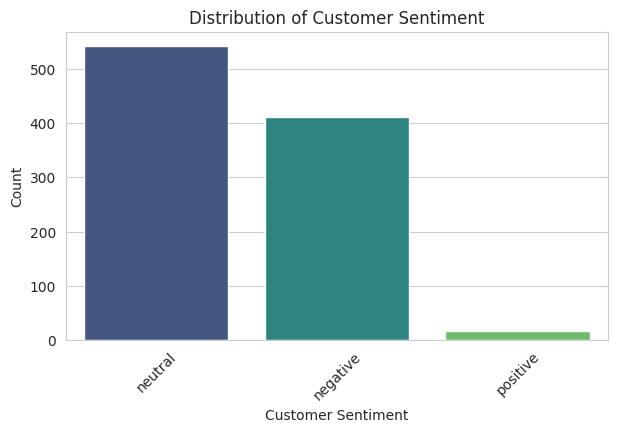

In [12]:
plt.figure(figsize=(7, 4))

palette = sns.color_palette("viridis", train["customer_sentiment"].nunique())

sns.countplot(
    data=train,
    x="customer_sentiment",
    order=train["customer_sentiment"].value_counts().index,
    palette=palette
)

plt.title("Distribution of Customer Sentiment")
plt.xlabel("Customer Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The target variable is clearly imbalanced. Neutral sentiment forms the majority class, negative sentiment is the second largest group, and positive sentiment appears only rarely. This imbalance is important because it will likely affect model learning and evaluation, especially for the positive class.

In [14]:
# ============================================================
# 5. Conversation Length Analysis
# ============================================================

train["char_length"] = train["conversation"].apply(lambda x: len(str(x)))
train["word_count"] = train["conversation"].apply(lambda x: len(str(x).split()))

In [15]:
print("Character Length Summary:")
display(train["char_length"].describe())

print("\nWord Count Summary:")
display(train["word_count"].describe())

Character Length Summary:


,char_length
count,970.000000
mean,2129.284536
std,564.751035
min,46.000000
25%,1760.250000
50%,2058.500000
75%,2430.000000
max,5708.000000



Word Count Summary:


,word_count
count,970.000000
mean,370.860825
std,98.267606
min,8.000000
25%,306.000000
50%,357.000000
75%,424.000000
max,992.000000


In [16]:
# Key percentiles for word count
p50 = np.percentile(train["word_count"], 50)
p75 = np.percentile(train["word_count"], 75)
p90 = np.percentile(train["word_count"], 90)
p95 = np.percentile(train["word_count"], 95)

print("Word Count Percentiles:")
print(f"50th percentile (median): {p50:.0f}")
print(f"75th percentile: {p75:.0f}")
print(f"90th percentile: {p90:.0f}")
print(f"95th percentile: {p95:.0f}")

Word Count Percentiles:
50th percentile (median): 357
75th percentile: 424
90th percentile: 494
95th percentile: 554


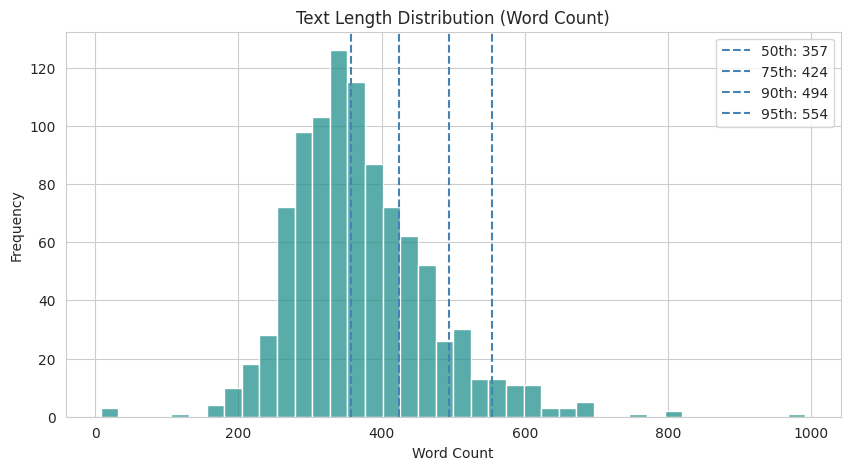

In [17]:
# Histogram of conversation lengths
plt.figure(figsize=(10, 5))

sns.histplot(
    train["word_count"],
    bins=40,
    color=sns.color_palette("viridis", 1)[0]
)

plt.axvline(p50, linestyle="--", color="steelblue", label=f"50th: {int(p50)}")
plt.axvline(p75, linestyle="--", color="steelblue", label=f"75th: {int(p75)}")
plt.axvline(p90, linestyle="--", color="steelblue", label=f"90th: {int(p90)}")
plt.axvline(p95, linestyle="--", color="steelblue", label=f"95th: {int(p95)}")

plt.title("Text Length Distribution (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Conversations are relatively long, with a median of 357 words and most samples falling between 300–450 words. The distribution is slightly right-skewed, with some very long conversations. This suggests that a reasonably high max token length (e.g., 512) is appropriate for modeling, though some truncation will still occur.

/tmp/ipykernel_3528/2642193872.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


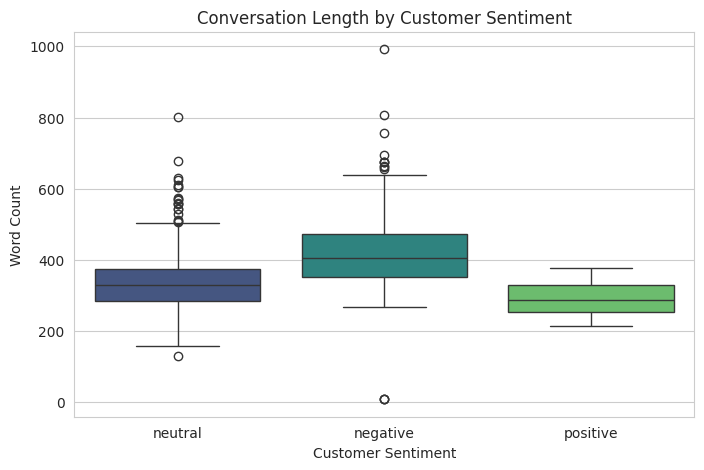

Word Count Summary by Sentiment:


,count,mean,std,min,25%,50%,75%,max
customer_sentiment,,,,,,,,
negative,411.0,417.67,101.35,8.0,351.5,406.0,471.5,992.0
neutral,542.0,337.78,80.60,129.0,285.0,329.0,373.0,802.0
positive,17.0,294.00,48.18,213.0,253.0,286.0,329.0,378.0


In [19]:
# Compare conversation length across sentiment classes
plt.figure(figsize=(8, 5))

palette = sns.color_palette("viridis", train["customer_sentiment"].nunique())

sns.boxplot(
    data=train,
    x="customer_sentiment",
    y="word_count",
    order=train["customer_sentiment"].value_counts().index,
    palette=palette
)

plt.title("Conversation Length by Customer Sentiment")
plt.xlabel("Customer Sentiment")
plt.ylabel("Word Count")
plt.show()

length_summary_by_sentiment = (
    train.groupby("customer_sentiment")["word_count"]
    .describe()
    .round(2)
)

print("Word Count Summary by Sentiment:")
display(length_summary_by_sentiment)

Negative conversations tend to be longer on average than neutral and positive ones, while positive conversations are generally shorter. This suggests that dissatisfied customers may provide more detailed explanations, which could help the model distinguish negative sentiment from others.

In [20]:
# ============================================================
# 6. Relationship Between Low-Cardinality Features and Sentiment
# ============================================================

features_to_analyze = [
    "issue_complexity",
    "agent_experience_level",
    "product_category",
    "issue_area"
]

# Crosstab tables for normalized sentiment distribution
for col in features_to_analyze:
    print(f"\nSentiment distribution by {col}:")

    table = pd.crosstab(
        train[col],
        train["customer_sentiment"],
        normalize="index"
    ).round(3)

    display(table)


Sentiment distribution by issue_complexity:


customer_sentiment,negative,neutral,positive
issue_complexity,,,
high,0.476,0.488,0.037
less,0.417,0.568,0.015
medium,0.421,0.562,0.017



Sentiment distribution by agent_experience_level:


customer_sentiment,negative,neutral,positive
agent_experience_level,,,
experienced,0.434,0.555,0.012
inexperienced,0.333,0.660,0.007
junior,0.443,0.533,0.024



Sentiment distribution by product_category:


customer_sentiment,negative,neutral,positive
product_category,,,
Appliances,0.419,0.562,0.020
Electronics,0.416,0.580,0.003
Men/Women/Kids,0.444,0.525,0.031



Sentiment distribution by issue_area:


customer_sentiment,negative,neutral,positive
issue_area,,,
Cancellations and returns,0.491,0.509,0.000
Login and Account,0.188,0.812,0.000
Order,0.605,0.329,0.066
Shipping,0.529,0.471,0.000
Shopping,0.319,0.681,0.000
Warranty,0.175,0.825,0.000


In [21]:
# Helper function for stacked percentage plots
def plot_stacked_sentiment(df, feature, target="customer_sentiment", figsize=(8, 5), rotation=0):
    sentiment_table = pd.crosstab(
        df[feature],
        df[target],
        normalize="index"
    ) * 100

    sentiment_table = sentiment_table.reindex(
        columns=["negative", "neutral", "positive"],
        fill_value=0
    ).round(1)

    palette = sns.color_palette("viridis", sentiment_table.shape[1])

    sentiment_table.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
        color=palette
    )

    plt.title(f"Sentiment Distribution by {feature} (%)")
    plt.xlabel(feature)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=rotation)
    plt.legend(title="Customer Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.ylim(0, 100)
    plt.show()

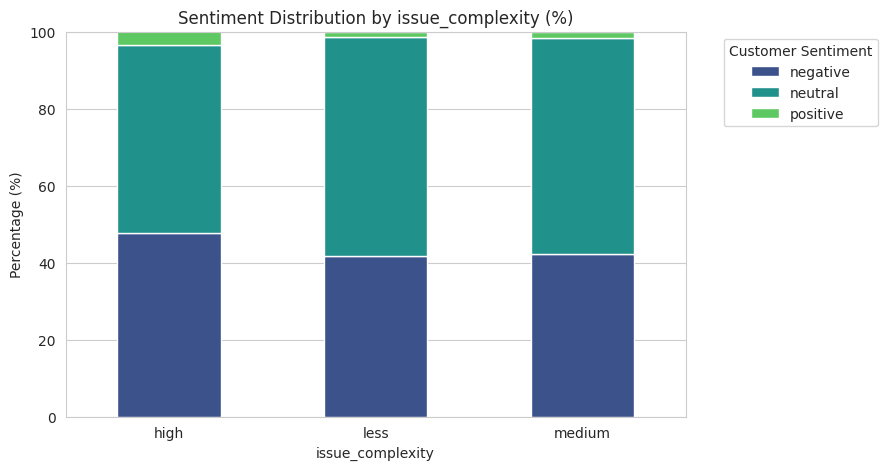

In [23]:
plot_stacked_sentiment(train, "issue_complexity", figsize=(8, 5), rotation=0)

Sentiment distribution is relatively similar across complexity levels, with slightly higher negative ratios for high-complexity issues. This suggests limited but intuitive impact of complexity on sentiment.

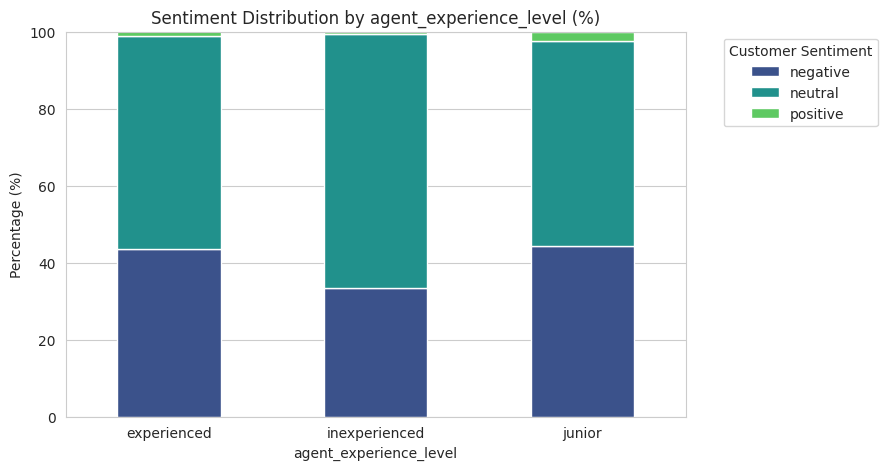

In [24]:
plot_stacked_sentiment(train, "agent_experience_level", figsize=(8, 5), rotation=0)

Less experienced agents tend to have slightly lower negative sentiment, while junior and experienced agents show similar distributions. Overall, agent experience does not show a strong relationship with sentiment.

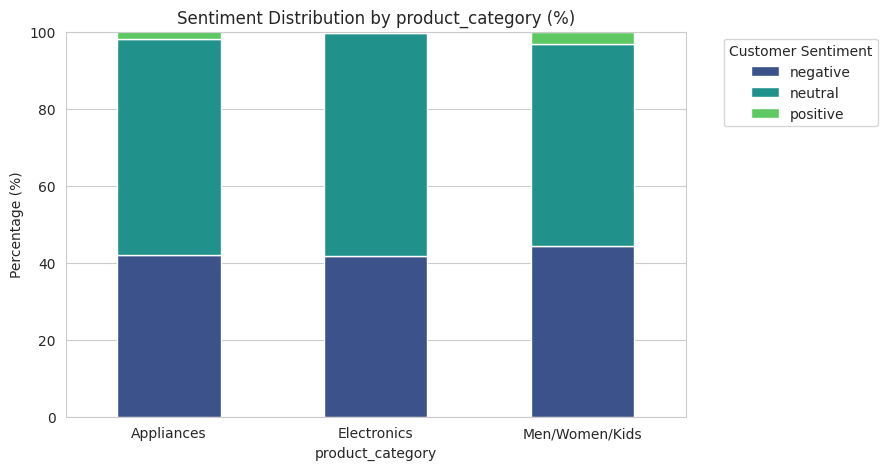

In [25]:
plot_stacked_sentiment(train, "product_category", figsize=(8, 5), rotation=0)

Sentiment distribution is quite similar across product categories, indicating that product type alone is not a strong driver of customer sentiment.

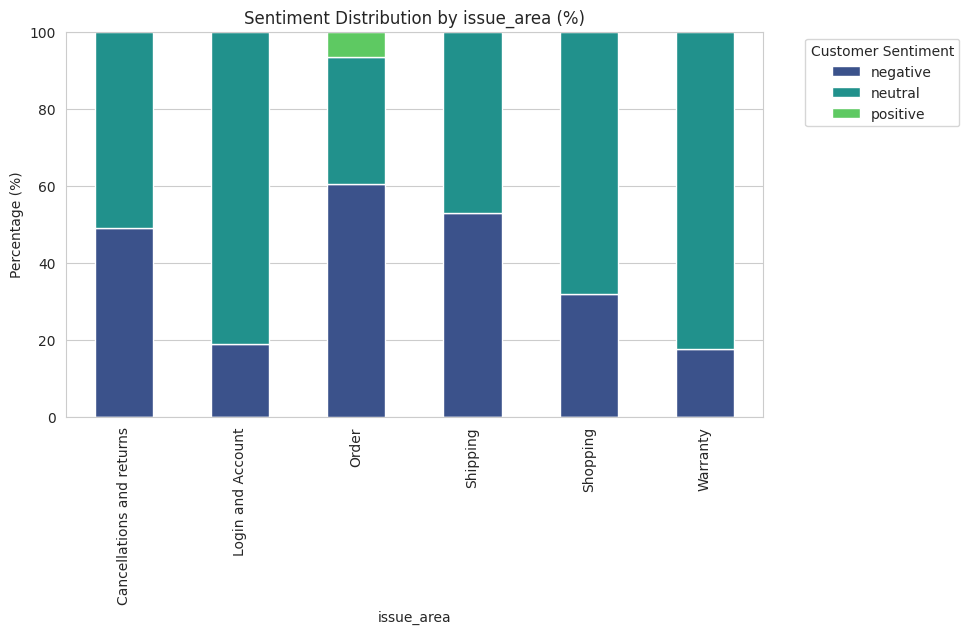

In [26]:
plot_stacked_sentiment(train, "issue_area", figsize=(9, 5), rotation=90)

Issue area shows clear variation in sentiment distribution. For example, "Order" and "Shipping" have higher negative ratios, while "Login and Account" and "Warranty" are mostly neutral. This suggests that issue area is a strong candidate for inclusion in the fusion model.

In [27]:
# ============================================================
# 7. Relationship Between High-Cardinality Features and Sentiment
# ============================================================

high_cardinality_cols = [
    "issue_category",
    "issue_sub_category",
    "issue_category_sub_category",
    "product_sub_category"
]

palette_counts = sns.color_palette("viridis", 10)
palette_sentiment = sns.color_palette("viridis", 3)

In [36]:
def plot_top10_and_sentiment(df, col):
    print(f"\nTop categories for {col}")

    top10 = df[col].value_counts().head(10)

    # Top-10 category frequency
    plt.figure(figsize=(10, 4))
    sns.barplot(
        x=top10.values,
        y=top10.index,
        palette=palette_counts
    )
    plt.title(f"Top 10 Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

    # Sentiment distribution within top-10 categories
    filtered = df[df[col].isin(top10.index)]

    sentiment_table = pd.crosstab(
        filtered[col],
        filtered["customer_sentiment"],
        normalize="index"
    ) * 100

    sentiment_table = sentiment_table.reindex(
        columns=["negative", "neutral", "positive"],
        fill_value=0
    ).round(1)

    sentiment_table.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5),
        color=palette_sentiment
    )
    plt.title(f"Sentiment Distribution for Top 10 {col} (%)")
    plt.xlabel(col)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=90)
    plt.legend(title="Customer Sentiment", bbox_to_anchor=(1.05, 1))
    plt.ylim(0, 100)
    plt.show()

    display(sentiment_table)


Top categories for issue_category


/tmp/ipykernel_3528/266345473.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


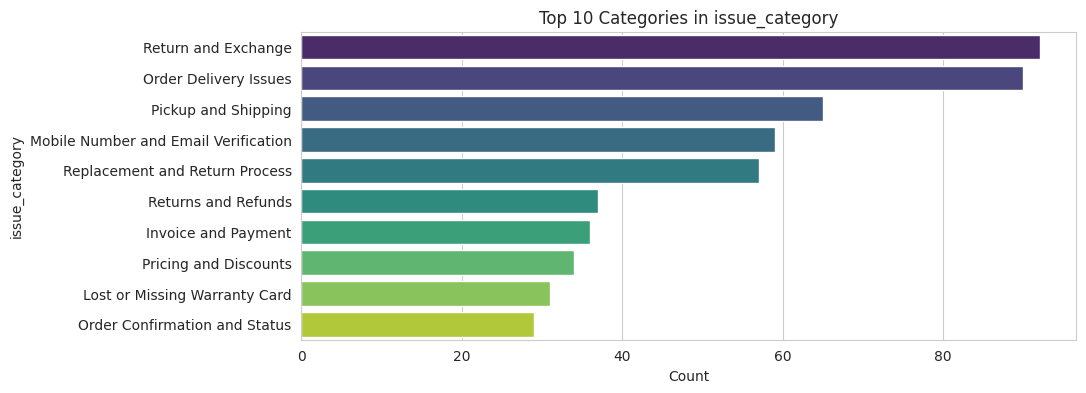

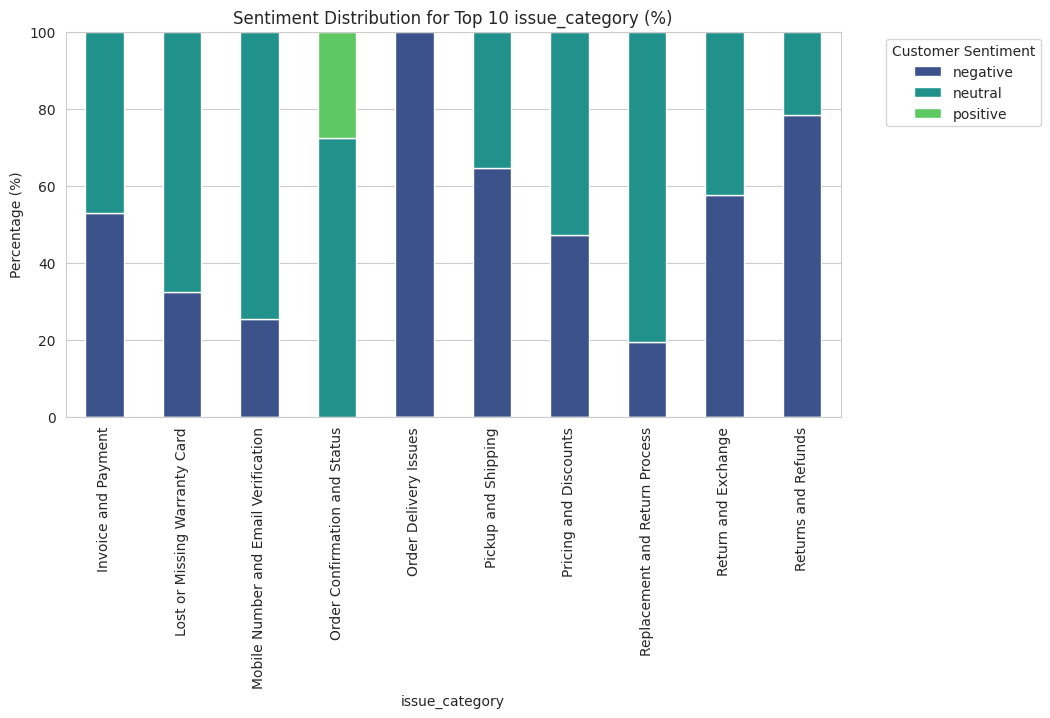

customer_sentiment,negative,neutral,positive
issue_category,,,
Invoice and Payment,52.8,47.2,0.0
Lost or Missing Warranty Card,32.3,67.7,0.0
Mobile Number and Email Verification,25.4,74.6,0.0
Order Confirmation and Status,0.0,72.4,27.6
Order Delivery Issues,100.0,0.0,0.0
Pickup and Shipping,64.6,35.4,0.0
Pricing and Discounts,47.1,52.9,0.0
Replacement and Return Process,19.3,80.7,0.0
Return and Exchange,57.6,42.4,0.0


In [37]:
# issue_category
plot_top10_and_sentiment(train, "issue_category")

A few categories such as "Return and Exchange" and "Order Delivery Issues" dominate the dataset, indicating class imbalance within this feature. These frequent categories may have a stronger influence on the model.


Top categories for issue_sub_category


/tmp/ipykernel_3528/266345473.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


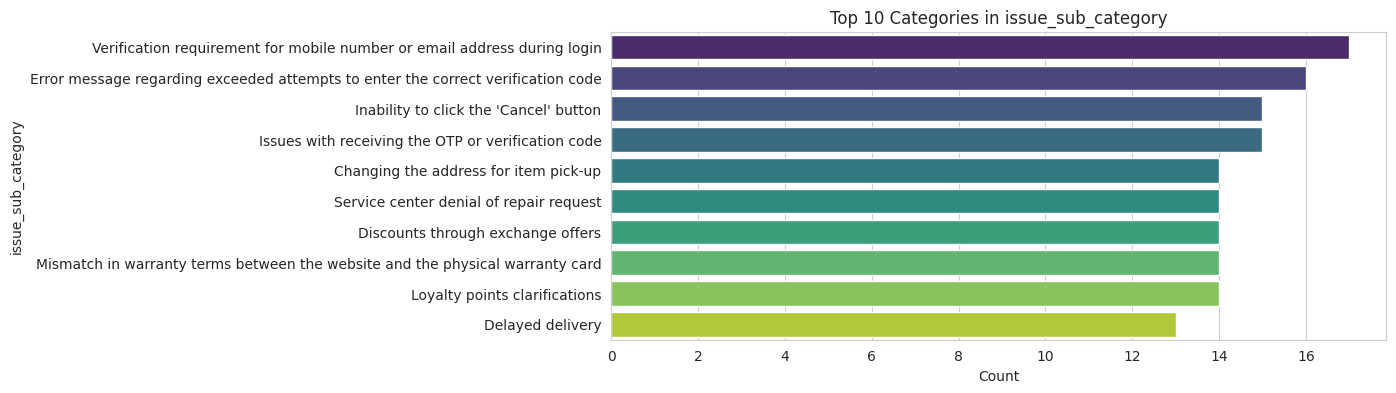

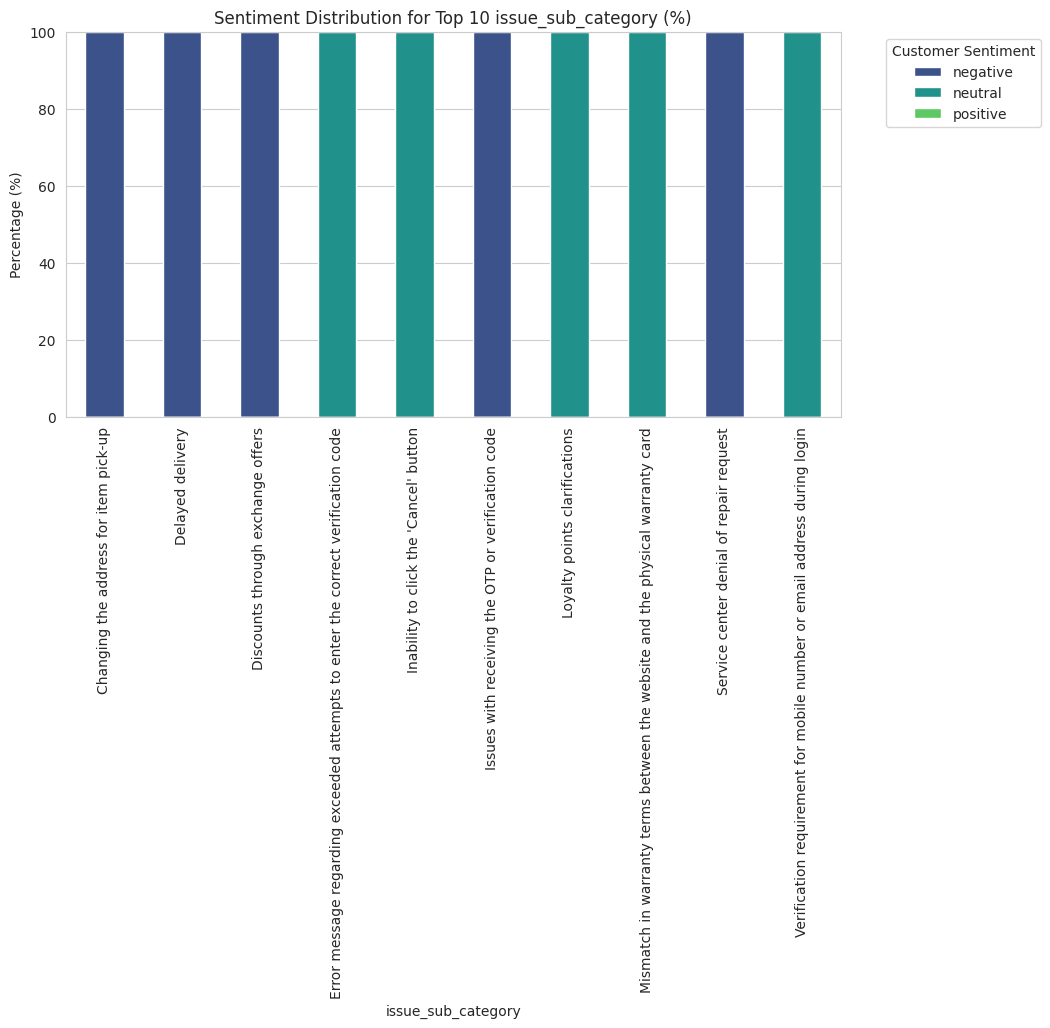

customer_sentiment,negative,neutral,positive
issue_sub_category,,,
Changing the address for item pick-up,100.0,0.0,0
Delayed delivery,100.0,0.0,0
Discounts through exchange offers,100.0,0.0,0
Error message regarding exceeded attempts to enter the correct verification code,0.0,100.0,0
Inability to click the 'Cancel' button,0.0,100.0,0
Issues with receiving the OTP or verification code,100.0,0.0,0
Loyalty points clarifications,0.0,100.0,0
Mismatch in warranty terms between the website and the physical warranty card,0.0,100.0,0
Service center denial of repair request,100.0,0.0,0


In [38]:
# issue_sub_category
plot_top10_and_sentiment(train, "issue_sub_category")

Sub-categories are more evenly distributed but still show recurring issue types, mainly related to verification, errors, and delivery problems. This level provides more detailed context than issue_category.


Top categories for issue_category_sub_category


/tmp/ipykernel_3528/266345473.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


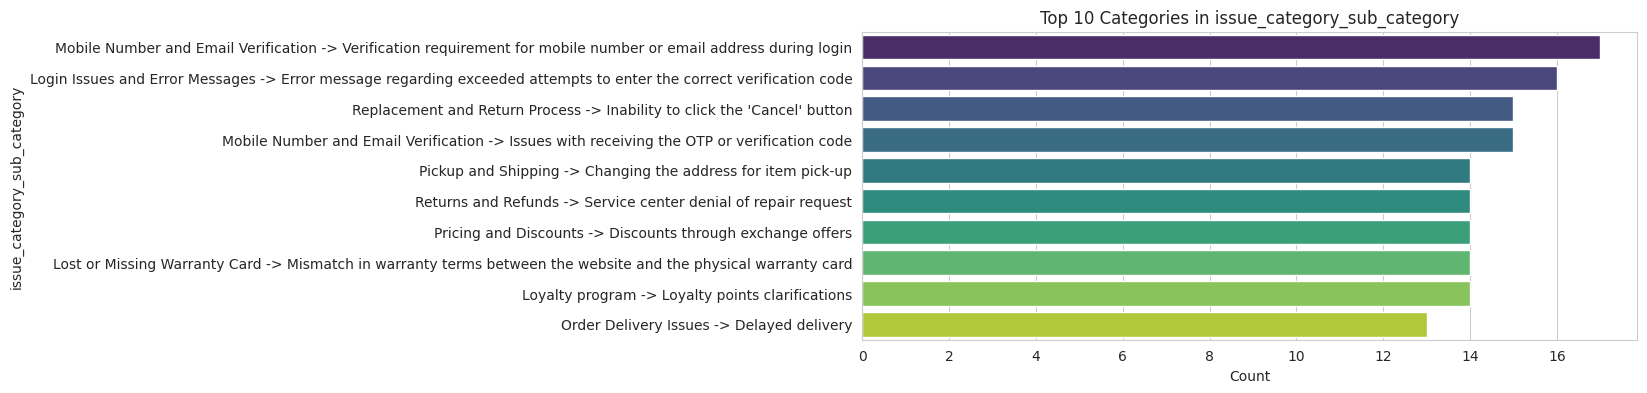

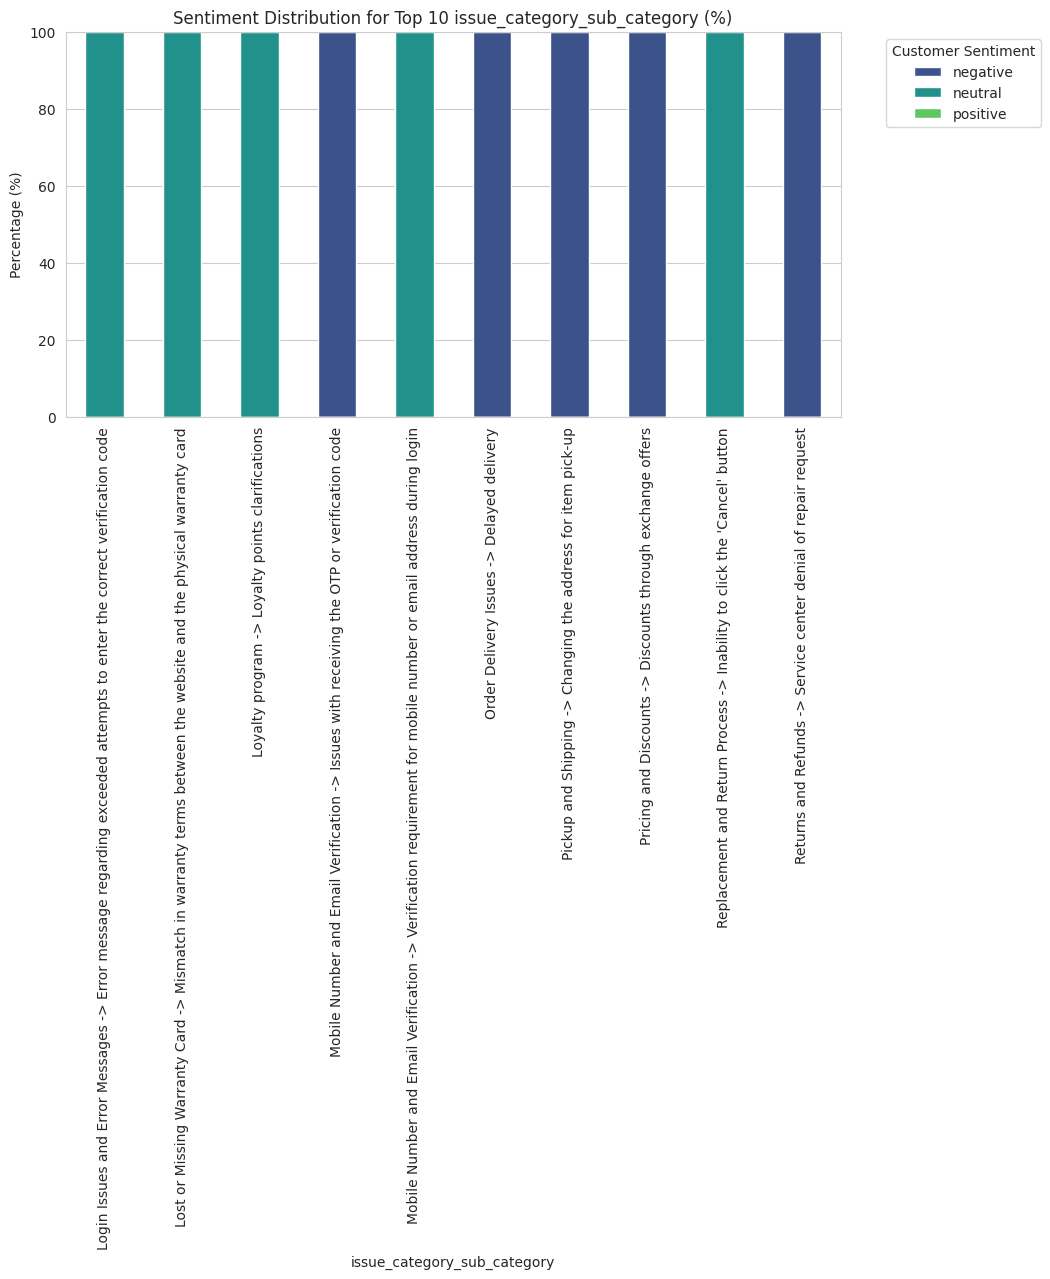

customer_sentiment,negative,neutral,positive
issue_category_sub_category,,,
Login Issues and Error Messages -> Error message regarding exceeded attempts to enter the correct verification code,0.0,100.0,0
Lost or Missing Warranty Card -> Mismatch in warranty terms between the website and the physical warranty card,0.0,100.0,0
Loyalty program -> Loyalty points clarifications,0.0,100.0,0
Mobile Number and Email Verification -> Issues with receiving the OTP or verification code,100.0,0.0,0
Mobile Number and Email Verification -> Verification requirement for mobile number or email address during login,0.0,100.0,0
Order Delivery Issues -> Delayed delivery,100.0,0.0,0
Pickup and Shipping -> Changing the address for item pick-up,100.0,0.0,0
Pricing and Discounts -> Discounts through exchange offers,100.0,0.0,0
Replacement and Return Process -> Inability to click the 'Cancel' button,0.0,100.0,0


In [39]:
# issue_category_sub_category
plot_top10_and_sentiment(train, "issue_category_sub_category")

This combined feature captures detailed issue hierarchies, but the distribution remains similar to sub-categories. While informative, it may introduce redundancy due to overlap with other issue-related features.


Top categories for product_sub_category


/tmp/ipykernel_3528/266345473.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


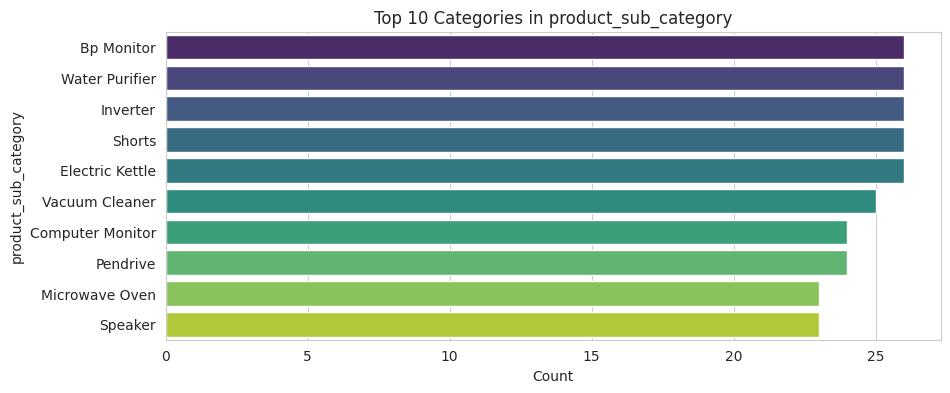

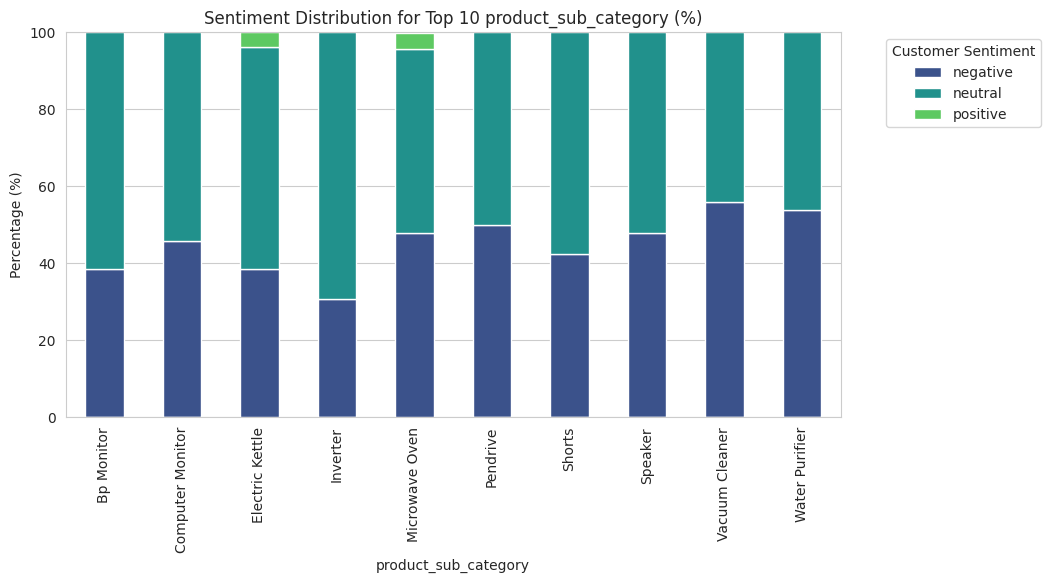

customer_sentiment,negative,neutral,positive
product_sub_category,,,
Bp Monitor,38.5,61.5,0.0
Computer Monitor,45.8,54.2,0.0
Electric Kettle,38.5,57.7,3.8
Inverter,30.8,69.2,0.0
Microwave Oven,47.8,47.8,4.3
Pendrive,50.0,50.0,0.0
Shorts,42.3,57.7,0.0
Speaker,47.8,52.2,0.0
Vacuum Cleaner,56.0,44.0,0.0


In [40]:
# product_sub_category
plot_top10_and_sentiment(train, "product_sub_category")

Product sub-categories are relatively balanced across different product types, suggesting that this feature may provide limited discriminative power for sentiment prediction.

In [29]:
# ============================================================
# 8. Feature Relevance Analysis
# ============================================================

features_for_relevance = [
    "issue_complexity",
    "agent_experience_level",
    "product_category",
    "issue_area",
    "issue_category",
    "issue_sub_category",
    "product_sub_category"
]

# Chi-Square Association
chi2_results = []

for col in features_for_relevance:
    contingency_table = pd.crosstab(train[col], train["customer_sentiment"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    chi2_results.append({
        "feature": col,
        "chi2_statistic": chi2,
        "degrees_of_freedom": dof,
        "p_value": p,
        "significant_at_0_05": "Yes" if p < 0.05 else "No"
    })

chi2_results_df = pd.DataFrame(chi2_results).sort_values("p_value").reset_index(drop=True)

print("Chi-Square Test Results:")
display(chi2_results_df)

Chi-Square Test Results:


,feature,chi2_statistic,degrees_of_freedom,p_value,significant_at_0_05
0,issue_sub_category,1940.000000,216,1.909643e-274,Yes
1,issue_category,1059.213726,78,6.586368e-172,Yes
2,issue_area,168.893250,10,4.701405e-31,Yes
3,agent_experience_level,9.259813,4,5.492353e-02,No
4,product_category,6.906161,4,1.409311e-01,No
5,issue_complexity,3.300219,4,5.088975e-01,No
6,product_sub_category,88.245879,98,7.496001e-01,No


In [30]:
# Mutual Information
X_mi = train[features_for_relevance].copy()
y_mi = train["customer_sentiment"].copy()

for col in X_mi.columns:
    le = LabelEncoder()
    X_mi[col] = le.fit_transform(X_mi[col])

target_le = LabelEncoder()
y_mi = target_le.fit_transform(y_mi)

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=True,
    random_state=42
)

mi_results_df = pd.DataFrame({
    "feature": features_for_relevance,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

print("Mutual Information Scores:")
display(mi_results_df)

Mutual Information Scores:


,feature,mutual_information
0,issue_sub_category,0.759935
1,issue_category,0.354769
2,issue_area,0.089940
3,product_sub_category,0.044173
4,agent_experience_level,0.004911
5,product_category,0.004177
6,issue_complexity,0.001503


In [31]:
feature_relevance_df = chi2_results_df.merge(
    mi_results_df,
    on="feature",
    how="left"
).sort_values(
    ["mutual_information", "p_value"],
    ascending=[False, True]
).reset_index(drop=True)

print("Combined Feature Relevance Summary:")
display(feature_relevance_df)

Combined Feature Relevance Summary:


,feature,chi2_statistic,degrees_of_freedom,p_value,significant_at_0_05,mutual_information
0,issue_sub_category,1940.000000,216,1.909643e-274,Yes,0.759935
1,issue_category,1059.213726,78,6.586368e-172,Yes,0.354769
2,issue_area,168.893250,10,4.701405e-31,Yes,0.089940
3,product_sub_category,88.245879,98,7.496001e-01,No,0.044173
4,agent_experience_level,9.259813,4,5.492353e-02,No,0.004911
5,product_category,6.906161,4,1.409311e-01,No,0.004177
6,issue_complexity,3.300219,4,5.088975e-01,No,0.001503


Both Chi-Square and Mutual Information results indicate that issue_sub_category, issue_category, and issue_area have the strongest relationship with customer sentiment. In contrast, features like agent_experience_level, product_category, and issue_complexity show weak or insignificant associations.
However, although issue_sub_category appears most informative, its high cardinality may lead to overfitting. Therefore, issue_category and issue_area provide a better balance between predictive power and generalization for use in the fusion model.

,customer_sentiment,issue_area,issue_category,issue_sub_category,product_category,product_sub_category,issue_complexity,agent_experience_level
customer_sentiment,1.000000,0.295057,0.738909,1.000000,0.059665,0.213278,0.041245,0.069088
issue_area,0.295057,1.000000,1.000000,1.000000,0.152096,0.215911,0.084038,0.073921
issue_category,0.738909,1.000000,1.000000,1.000000,0.222982,0.207082,0.204713,0.200827
issue_sub_category,1.000000,1.000000,1.000000,1.000000,0.337672,0.305989,0.347369,0.326013
product_category,0.059665,0.152096,0.222982,0.337672,1.000000,1.000000,0.006056,0.034505
product_sub_category,0.213278,0.215911,0.207082,0.305989,1.000000,1.000000,0.194686,0.242098
issue_complexity,0.041245,0.084038,0.204713,0.347369,0.006056,0.194686,1.000000,0.026147
agent_experience_level,0.069088,0.073921,0.200827,0.326013,0.034505,0.242098,0.026147,1.000000


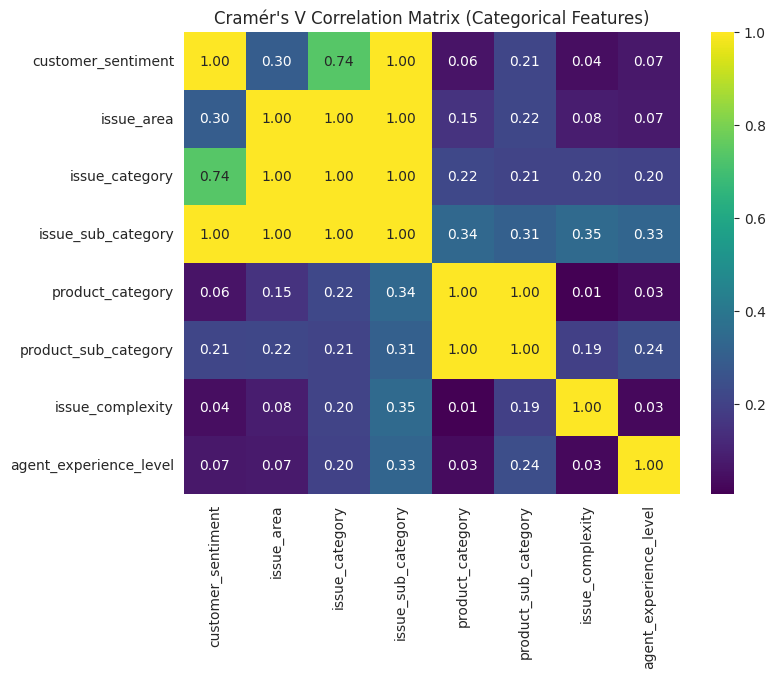

In [34]:
# ============================================================
# 9. Correlation Between Categorical Features
# ============================================================

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))


corr_features = [
    "customer_sentiment",
    "issue_area",
    "issue_category",
    "issue_sub_category",
    "product_category",
    "product_sub_category",
    "issue_complexity",
    "agent_experience_level",
]

cramers_matrix = pd.DataFrame(index=corr_features, columns=corr_features)

for col1 in corr_features:
    for col2 in corr_features:
        cramers_matrix.loc[col1, col2] = cramers_v(train[col1], train[col2])

cramers_matrix = cramers_matrix.astype(float)

display(cramers_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Cramér's V Correlation Matrix (Categorical Features)")
plt.show()

Issue-related features (issue_area, issue_category, issue_sub_category) show strong correlations with each other, indicating redundancy due to their hierarchical structure. Among them, issue_category and issue_area still maintain meaningful correlation with the target. In contrast, product-related features and agent experience show weak relationships with sentiment. This supports selecting a limited set of issue-level features to avoid redundancy in the fusion model.

,feature,importance
1,issue_category,0.383603
2,issue_sub_category,0.287486
0,issue_area,0.277528
4,product_sub_category,0.026684
6,agent_experience_level,0.011502
5,issue_complexity,0.007742
3,product_category,0.005456


/tmp/ipykernel_3528/2941632516.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


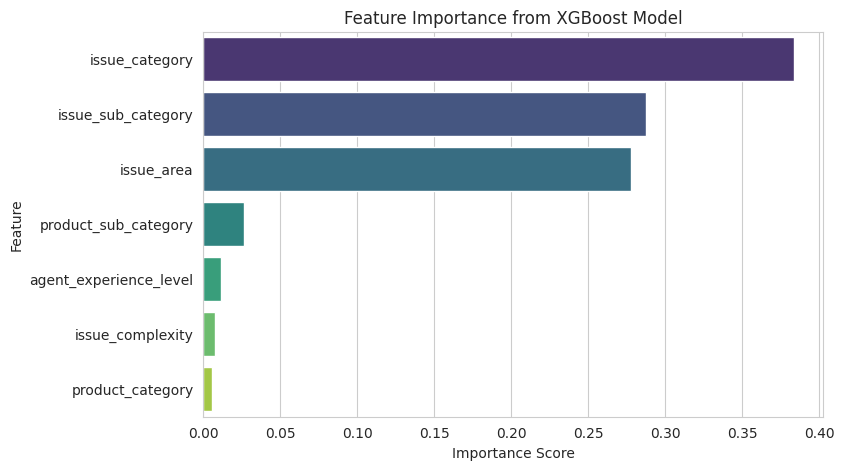

In [35]:
# ============================================================
# 10. Feature Importance from a Baseline Structured Model
# ============================================================

model_features = [
    "issue_area",
    "issue_category",
    "issue_sub_category",
    "product_category",
    "product_sub_category",
    "issue_complexity",
    "agent_experience_level",
]

X_model = train[model_features].copy()
y_model = train["customer_sentiment"].copy()

label_encoders = {}

for col in X_model.columns:
    le = LabelEncoder()
    X_model[col] = le.fit_transform(X_model[col])
    label_encoders[col] = le

target_encoder = LabelEncoder()
y_model = target_encoder.fit_transform(y_model)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_model, y_model)

importance_df = pd.DataFrame({
    "feature": model_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    palette=sns.color_palette("viridis", len(importance_df))
)

plt.title("Feature Importance from XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

This result is based on a model using only structured categorical features (without conversation). It shows that issue_category, issue_sub_category, and issue_area carry most of the predictive signal among structured variables, while product-related features and agent experience contribute very little.

### Overall Summary

The dataset is clean but highly imbalanced. Conversations are relatively long, supporting higher token lengths. Issue-related features (issue_area, issue_category) show the strongest relationship with sentiment, while others add limited value. These findings motivate using text with selected issue-level features in the fusion model.